# Imports

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tqdm import tqdm
import time
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, IntSlider, Layout, fixed
from sklearn.decomposition import PCA
from scipy.stats import pointbiserialr, ttest_ind, pearsonr, t
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from statsmodels.stats.mediation import Mediation
from scipy import stats
import pingouin as pg
import hdbscan
from scipy.stats import f_oneway

# Exploratory Data Analysis

## Dataset 1: Social Anxiety Dataset
https://www.kaggle.com/datasets/natezhang123/social-anxiety-dataset

### Variables in the Dataset:
- Anxiety Level (1-10): Target variable
- Age
- Gender
- Occupation
- Sleep Hours
- Physical Activity (hrs/week)
- Caffeine Intake (mg/day)
- Alcohol Consumption (drinks/week)
- Smoking
- Family History of Anxiety
- Stress Level (1-10)
- Heart Rate (bpm)
- Breathing Rate (breaths/min)
- Sweating Level (1-5)
- Dizziness
- Medication
- Therapy Sessions (per month)
- Recent Major Life Event
- Diet Quality (1-10)


In [4]:
data_path = "..\\data"
social_anxiety_dataset_name = "enhanced_anxiety_dataset.csv"
df = pd.read_csv(os.path.join(data_path, social_anxiety_dataset_name))

Change "Yes", "No" columns to binary (0,1)

In [5]:
binary_cols = ['Medication', 'Smoking', 'Family History of Anxiety', 'Recent Major Life Event', 'Dizziness']
for col in binary_cols:
    df[col] = df[col].map({'Yes': True, 'No': False})

One hot encode Gender and Ocupation

In [6]:
df = pd.get_dummies(df, columns=['Gender'])
df = pd.get_dummies(df, columns=['Occupation'])

Convert bool to integer

In [7]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

### Get basic dataset properties

In [8]:
print("Dataset Info:")
print(df.info())

missing_cols = df.columns[df.isnull().sum() > 0].tolist()
print(f"\nColumns with missing values: {missing_cols}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Sleep Hours                        11000 non-null  float64
 2   Physical Activity (hrs/week)       11000 non-null  float64
 3   Caffeine Intake (mg/day)           11000 non-null  int64  
 4   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 5   Smoking                            11000 non-null  int64  
 6   Family History of Anxiety          11000 non-null  int64  
 7   Stress Level (1-10)                11000 non-null  int64  
 8   Heart Rate (bpm)                   11000 non-null  int64  
 9   Breathing Rate (breaths/min)       11000 non-null  int64  
 10  Sweating Level (1-5)               11000 non-null  int64  
 11  Dizziness                          11000

In [9]:
df.describe()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),...,Occupation_Doctor,Occupation_Engineer,Occupation_Freelancer,Occupation_Lawyer,Occupation_Musician,Occupation_Nurse,Occupation_Other,Occupation_Scientist,Occupation_Student,Occupation_Teacher
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,...,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,40.241727,6.650691,2.942136,286.090000,9.701636,0.525364,0.531545,5.856364,90.916000,20.957545,...,0.076545,0.075727,0.076182,0.073545,0.081091,0.078273,0.076364,0.075636,0.079818,0.073364
std,13.236140,1.227509,1.827825,144.813157,5.689713,0.499379,0.499027,2.927202,17.325721,5.160107,...,0.265881,0.264573,0.265301,0.261042,0.272987,0.268612,0.265591,0.264427,0.271024,0.260744
min,18.000000,2.300000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,60.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,5.900000,1.500000,172.000000,5.000000,0.000000,0.000000,3.000000,76.000000,17.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,40.000000,6.700000,2.800000,273.000000,10.000000,1.000000,1.000000,6.000000,92.000000,21.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,51.000000,7.500000,4.200000,382.000000,15.000000,1.000000,1.000000,8.000000,106.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,64.000000,11.300000,10.100000,599.000000,19.000000,1.000000,1.000000,10.000000,119.000000,29.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Invert features for interpretability
Structure all features so that a low number generally mean -> good, health, normal and high number is rather critical. Important for  correlation analysis

In [10]:
df['Sleep Hours'] *= -1
df['Diet Quality (1-10)'] *= -1
df['Physical Activity (hrs/week)'] *= -1

### Composite scores
- **Psychological Stress** (Heart Rate, Breath Rate, Sweatlevel,Dizziness )
- **Lifestyle Risk** (Sleeping Hours, Caffein Intake, Alcohol Consumption, Smoking, Diet Quality)
- **Psychological Vulnerability** (Familiy History, Medication, Therapy Session, Recent Major Life Event)

In [11]:
composite_features = ['Physiological_Stress_Score', 'Psychosocial_Vulnerability_Score','Lifestyle_Risk_Score']

physio_cols = ['Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness']
df[composite_features[0]] = StandardScaler().fit_transform(df[physio_cols]).mean(axis=1)

psycho_cols = ['Family History of Anxiety', 'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event']
df[composite_features[1]] = StandardScaler().fit_transform(df[psycho_cols]).mean(axis=1)

lifestyle_cols = ['Sleep Hours', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Smoking', 'Diet Quality (1-10)', 'Physical Activity (hrs/week)']
df[composite_features[2]] = StandardScaler().fit_transform(df[lifestyle_cols]).mean(axis=1)

### Histograms for Numerical and Binary Features

In [12]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

numeric_cols = [col for col in df.select_dtypes(include='number') if not col.startswith(('Gender_', 'Occupation_'))]
tabs = []
tab_titles = []

for col in numeric_cols:
    out = widgets.Output()
    with out:
        data = df[col].dropna()
        mean = data.mean()
        std = data.std()

        fig, ax = plt.subplots()
        ax.hist(data, bins=30, color='skyblue', edgecolor='black')
        ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean:.2f}')
        ax.axvline(mean + std, color='green', linestyle=':', linewidth=2, label=f'+1 Std = {mean + std:.2f}')
        ax.axvline(mean - std, color='green', linestyle=':', linewidth=2, label=f'-1 Std = {mean - std:.2f}')

        ax.set_title(f'Histogram of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.legend()
        plt.tight_layout()
        plt.show()

    tabs.append(out)
    tab_titles.append(col)

tab_widget = widgets.Tab(children=tabs)
for i, title in enumerate(tab_titles):
    tab_widget.set_title(i, title)

display(tab_widget)

### Histogram for Categorical Features

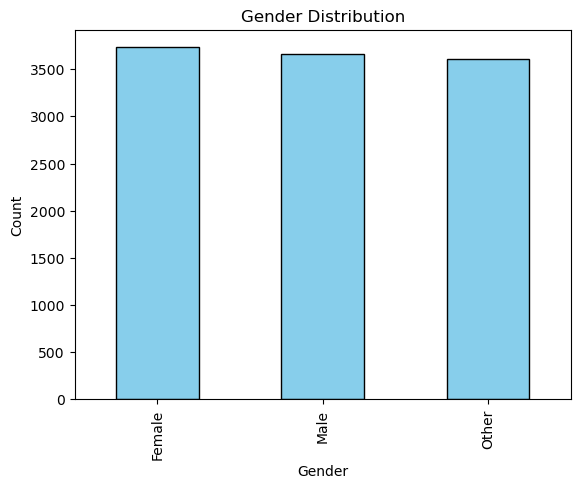

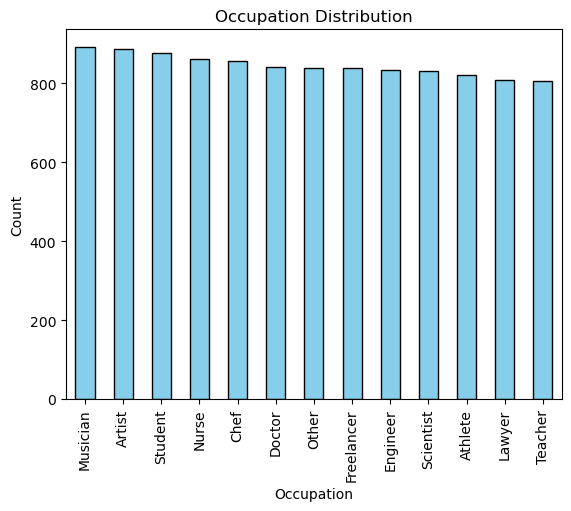

In [13]:
gender_cols = ['Gender_Male', 'Gender_Female', 'Gender_Other']
occupation_cols = ['Occupation_Artist','Occupation_Athlete', 'Occupation_Chef', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Freelancer', 'Occupation_Lawyer', 'Occupation_Musician', 'Occupation_Nurse', 'Occupation_Other', 'Occupation_Scientist', 'Occupation_Student', 'Occupation_Teacher']


df[gender_cols].idxmax(axis=1).str.replace('Gender_', '').value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

df[occupation_cols].idxmax(axis=1).str.replace('Occupation_', '').value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Occupation Distribution')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.show()

### Dimensionality Reduction

Remove categorical and composite features

In [17]:
dim_reduction_df = df.select_dtypes(include=['int64', 'float64']).iloc[:, :16]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dim_reduction_df)

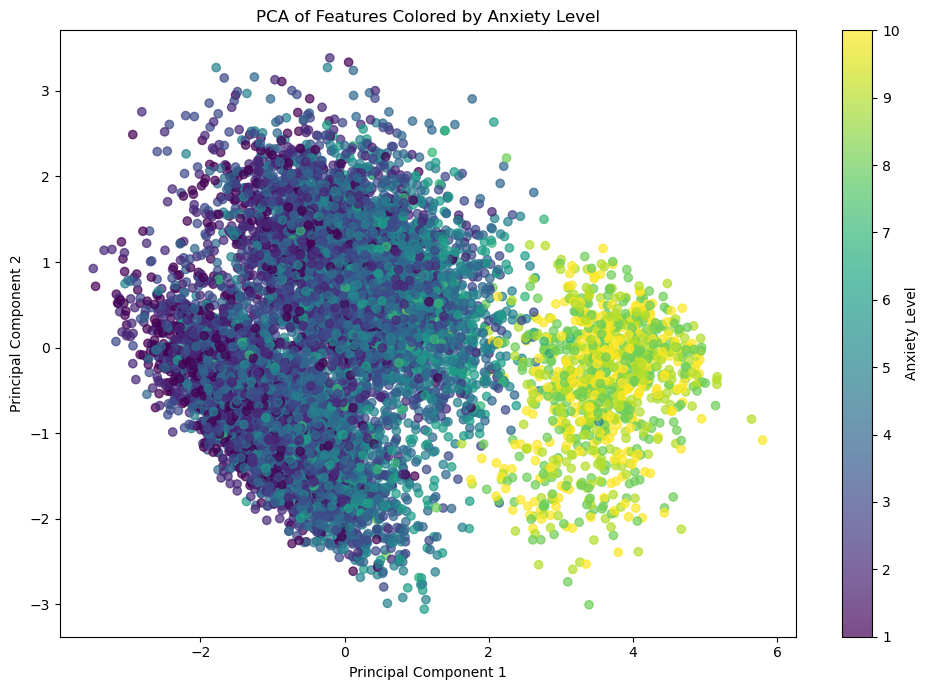

In [18]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=df['Anxiety Level (1-10)'],
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(scatter, label='Anxiety Level')
plt.title('PCA of Features Colored by Anxiety Level')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()

plt.savefig('pca_anxiety_colored.png', dpi=300)

plt.show()

In [20]:
perplexity_values = range(5,51,5)
tsne_time_per_iteration = []
X_tsnes = []
for n in tqdm(perplexity_values, desc="t-SNE Progress"):
    start_iter_time = time.time()
    tsne = TSNE(n_components=2, perplexity=n)
    X_tsnes.append(tsne.fit_transform(X_scaled))
    tsne_time_per_iteration.append(time.time() - start_iter_time)

t-SNE Progress: 100%|██████████████████████████████████████████████████████████████████| 10/10 [10:42<00:00, 64.30s/it]


Save and Load computed t-SNE

In [21]:
np.save(os.path.join(data_path,'tsne_list.npy'), X_tsnes)

In [15]:
X_tsnes = np.load(os.path.join(data_path,'tsne_list.npy'))

Plot t-SNE

In [22]:
def plot_dim_reduction(parameter,X_list, model_name, parameter_name):
    index = parameter-4
    if index != 0:
        index = int(index / 2)
    X = X_list[index]
    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=df['Anxiety Level (1-10)'],
        cmap='viridis',
        alpha=0.7,
        s=1
    )
    plt.colorbar(scatter, label='Anxiety Level')
    plt.title(f'{model_name} Visualization with {parameter_name} = {parameter}')
    plt.xlabel(f'{model_name} 1')
    plt.ylabel(f'{model_name} 2')
    plt.show()

In [23]:
perplexity_slider = IntSlider(value=20, min=4, max=50, step=2, description='Perplexity:',layout=Layout(width='700px'))
interact(plot_dim_reduction, parameter=perplexity_slider, X_list=fixed(X_tsnes), model_name=fixed("t-SNE"), parameter_name=fixed("Perplexity"));

interactive(children=(IntSlider(value=20, description='Perplexity:', layout=Layout(width='700px'), max=50, min…

# RQ 1: Do psychosocial, behaviour/lifestyle and physiological factors significantly influence anxiety levels?
First check how the composite scores of physiological and behavioral factors are related with correlation and t test(two sided). Choose alpha to 5%

In [15]:
target_column_name = 'Anxiety Level (1-10)'
df_test_results = pd.DataFrame(columns=["Physiological Stress","Psychosocial Vulnearability", "Lifestyle Risk"])

# test significance level
alpha = 0.05

# again show the features
print(f" Features inside the composite: {str(physio_cols)}")
print(f" Features inside the composite: {str(psycho_cols)}")
print(f" Features inside the composite: {str(lifestyle_cols)}")

 Features inside the composite: ['Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness']
 Features inside the composite: ['Family History of Anxiety', 'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event']
 Features inside the composite: ['Sleep Hours', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Smoking', 'Diet Quality (1-10)', 'Physical Activity (hrs/week)']


## Helper

In [16]:
def execute_t_test(comosite_feature_name, target_column_name):
    median_value = df[comosite_feature_name].median()
    group = df[comosite_feature_name] > median_value  
    high_group = df[group][target_column_name]
    low_group =df[~group][target_column_name]
    
    t_stat, p_value = ttest_ind(high_group, low_group)
    
    print(f"T-statistic: {t_stat:}")
    print(f"P-value: {p_value:}")
    if p_value < alpha:
        print("H_0 is rejected.")
    else:
        print("H_0 cannot be rejected.")
    d_ttest = cohens_d_ttest(high_group, low_group)
    print(f"Cohen's d (t-test): {d_ttest}")
    return p_value, d_ttest

def execute_correlation_test(comosite_feature_name, target_column_name):
    r_value, p_value = pearsonr(df[comosite_feature_name], df[target_column_name])
    print(f"Pearson correlation coefficient (r): {r_value:.3f}")
    print(f"p-value: {p_value:.4f}")
    
    if p_value < alpha:
        print("H_0 is rejected.")
    else:
        print("H_0 cannot be rejected.")
    
    return r_value, p_value


In [17]:
def cohens_d_ttest(group1, group2):
    n1, n2 = len(group1), len(group2)
    s1, s2 = group1.std(), group2.std()
    pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    d = (group1.mean() - group2.mean()) / pooled_std
    return d

## T test: Check if mean anxiety same for composites

$H_0$: The mean anxiety level is the same for low and high physiological activation <br>

In [18]:
print(f"t-test for: {composite_features[0]}")
_, cohensd_physiological = execute_t_test(composite_features[0], target_column_name)

t-test for: Physiological_Stress_Score
T-statistic: 24.47929404820782
P-value: 6.648386716084722e-129
H_0 is rejected.
Cohen's d (t-test): 0.4668018217221633


$H_0$: The mean anxiety level is the same for low and high for critical psychological history <br>

In [19]:
print(f"t-test for: {composite_features[1]}")
_, cohensd_psychological = execute_t_test(composite_features[1], target_column_name)

t-test for: Psychosocial_Vulnerability_Score
T-statistic: 27.042052173009587
P-value: 5.568433237622638e-156
H_0 is rejected.
Cohen's d (t-test): 0.5156853398075879


$H_0$: The mean anxiety level is the same for low and high for critical lifestyle and behaviour choices <br>

In [20]:
print(f"t-test for: {composite_features[2]}")
_, cohensd_lifestyle = execute_t_test(composite_features[2], target_column_name)


t-test for: Lifestyle_Risk_Score
T-statistic: 33.18227188925858
P-value: 3.4168768290055476e-230
H_0 is rejected.
Cohen's d (t-test): 0.6327610974516688


In [21]:
# add to table
df_test_results.loc[0] = [cohensd_physiological, cohensd_psychological, cohensd_lifestyle]

## Correlation Test: Check if anxiety and composites are linearly related

$H_0$: There is a no correlation between the physiological activation and the anxiety level <br>

In [22]:
print(f"Correlation Test for: {composite_features[0]}")
corr_physiological,_ = execute_correlation_test(composite_features[0], target_column_name)

Correlation Test for: Physiological_Stress_Score
Pearson correlation coefficient (r): 0.282
p-value: 0.0000
H_0 is rejected.


$H_0$: There is no correlation between critical pychology history and the anxiety level <br>

In [23]:
print(f"Correlation Test for: {composite_features[1]}")
corr_psychological,_ = execute_correlation_test(composite_features[1], target_column_name)

Correlation Test for: Psychosocial_Vulnerability_Score
Pearson correlation coefficient (r): 0.366
p-value: 0.0000
H_0 is rejected.


$H_0$: There is no correlation between the behaviour lifestyle and the anxiety level <br>

In [24]:
print(f"Correlation Test for: {composite_features[2]}")
corr_lifestyle,_ = execute_correlation_test(composite_features[2], target_column_name)

Correlation Test for: Lifestyle_Risk_Score
Pearson correlation coefficient (r): 0.517
p-value: 0.0000
H_0 is rejected.


In [25]:
# add to table
df_test_results.loc[1] = [corr_physiological, corr_psychological, corr_lifestyle]

**Interpretation**: For all test the hypothesis could be rejected hinting at some relation in both categories. The behavior/lifestyle link is a bit stronger. Even though making no specific claims about individual features

## Check with Permutation importance the effect strength 

In [26]:
X = df[[composite_features[0],composite_features[1],composite_features[2]]]
y = df[target_column_name]

model = LinearRegression()
model.fit(X, y)

print("Train R2:", r2_score(y, model.predict(X)))
cv_r2 = cross_val_score(model, X, y, scoring='r2', cv=5)
print("CV R2:", np.mean(cv_r2))


perm = permutation_importance(model, X, y, n_repeats=30, random_state=0)
for i, col in enumerate(X.columns):
    print(f"{col}: {perm.importances_mean[i]} +/- {perm.importances_std[i]}")

Train R2: 0.3489675594735079
CV R2: 0.34788490073496015
Physiological_Stress_Score: 0.042382593673566164 +/- 0.0026492330750964507
Psychosocial_Vulnerability_Score: 0.11640928168666019 +/- 0.0035715344172853915
Lifestyle_Risk_Score: 0.3609738932272003 +/- 0.008850059313343516


In [27]:
# add to table
df_test_results.loc[2] = [perm.importances_mean[0], perm.importances_mean[1], perm.importances_mean[2]]

In [28]:
df_test_results.index = ['Cohensd T-Test', 'Correlation', "Permutation Importance"]
df_test_results

,Physiological Stress,Psychosocial Vulnearability,Lifestyle Risk
Cohensd T-Test,0.466802,0.515685,0.632761
Correlation,0.282250,0.365816,0.517004
Permutation Importance,0.042383,0.116409,0.360974


**Interpretation**: The permutation importance shows a discrepancy between correlation and premutation importance. Eventually  we expect some correaltion between pychological and physiological features because of shared varience. Lifestyle seem to be the most relevant feature for anxiety level. <br>  
Also Regression shows that the three composites are explaining roughly 35% of the variance

## Show correlation strength between the two composites

$H_0$: There is a positive correlation between the physiological stress and the psychosocial vulnerability <br>

In [29]:
execute_correlation_test(composite_features[0], composite_features[1])

Pearson correlation coefficient (r): 0.147
p-value: 0.0000
H_0 is rejected.


(np.float64(0.14735879204738078), np.float64(1.911104313585456e-54))

$H_0$: There is a positive correlation between the physiological stress and lifestyle risk <br>

In [30]:
execute_correlation_test(composite_features[0], composite_features[2])

Pearson correlation coefficient (r): 0.237
p-value: 0.0000
H_0 is rejected.


(np.float64(0.23675365313233576), np.float64(5.559238110764933e-140))

$H_0$: There is a positive correlation between psychosocial vulnerability and lifestyle risk<br>

In [31]:
execute_correlation_test(composite_features[1], composite_features[2])

Pearson correlation coefficient (r): 0.241
p-value: 0.0000
H_0 is rejected.


(np.float64(0.24141819673949783), np.float64(1.2213764766267258e-145))

**Interpretation**: The weak correlation of pychological and psychological and high correlation to lifestyle indeed suggest that lifestyle acts as a cofounding variable. 

## Look at partial correlations to show if any independent effect is there 

$H_0$: There is no linear association between Anxiety Level and Psychosocial Vulnerability after controlling for Lifestyle Risks

In [32]:
pcorr = pg.partial_corr(data=df,
                        x=composite_features[1],
                        y=target_column_name,
                        covar=composite_features[2],
                        method='pearson')
print(pcorr)

             n         r         CI95%          p-val
pearson  11000  0.290131  [0.27, 0.31]  2.763512e-212


$H_0$: There is no linear association between Anxiety Level and Physiological Stress after controlling for Lifestyle Risks

In [33]:
pcorr = pg.partial_corr(data=df,
                        x=composite_features[0],
                        y=target_column_name,
                        covar=composite_features[2],
                        method='pearson')
print(pcorr)

             n         r         CI95%         p-val
pearson  11000  0.192206  [0.17, 0.21]  5.085347e-92


**Interpetation**: We cant say psychology and physiology have no effect as indepentent variables. Still we can assume some kind of shared influence even if it is not extremely strong

## Make a correlation analysis of the individual features

Split features into binary and continous. Remove categorical like gender and occupation

In [34]:
continuous_df = df.select_dtypes(include=['float64', 'int64'])
continuous_df = continuous_df.loc[:, continuous_df.nunique() > 2]
continuous_df = continuous_df.drop(columns=composite_features)

binary_df = df.loc[:, [col for col in df.columns if df[col].nunique() == 2 and set(df[col].dropna().unique()) <= {0, 1}]]
binary_df = binary_df.drop(columns=gender_cols)
binary_df = binary_df.drop(columns=occupation_cols)
print(binary_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Smoking                    11000 non-null  int64
 1   Family History of Anxiety  11000 non-null  int64
 2   Dizziness                  11000 non-null  int64
 3   Medication                 11000 non-null  int64
 4   Recent Major Life Event    11000 non-null  int64
dtypes: int64(5)
memory usage: 429.8 KB
None


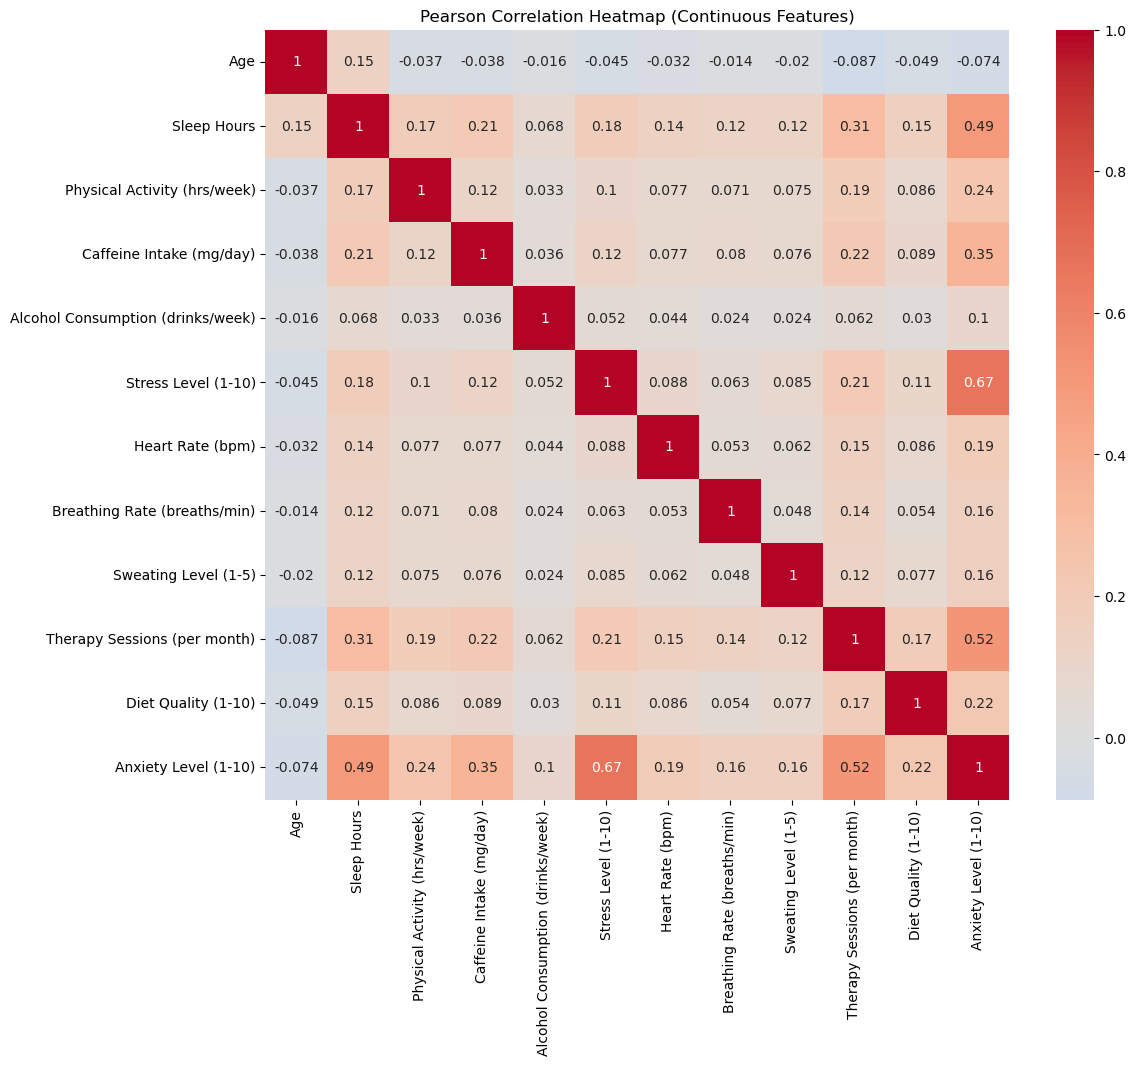

In [35]:
continuous_corr_matrix = corr_matrix = continuous_df.corr(method='pearson')  
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Pearson Correlation Heatmap (Continuous Features)')
plt.show()

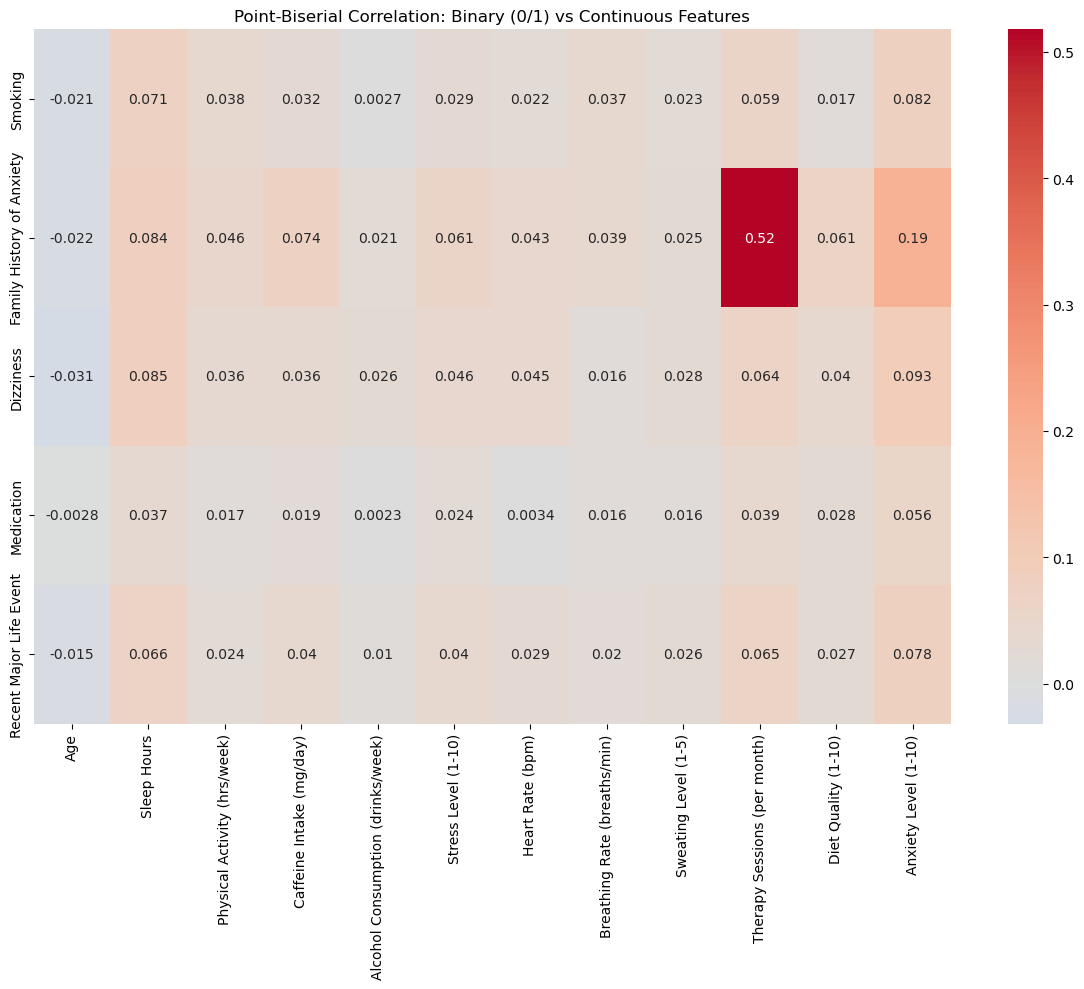

In [36]:
corr_matrix = pd.DataFrame(index=binary_df.columns, columns=continuous_df.columns, dtype=float)

for bin_col in binary_df.columns:
    for cont_col in continuous_df.columns:
        try:
            r, _ = pointbiserialr(df[bin_col], df[cont_col])
            corr_matrix.at[bin_col, cont_col] = r
        except Exception:
            corr_matrix.at[bin_col, cont_col] = None  # in case of missing or invalid data
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', center=0)
plt.title('Point-Biserial Correlation: Binary (0/1) vs Continuous Features')
plt.tight_layout()
plt.savefig('corr_binary_to_continuos.png')
plt.show()

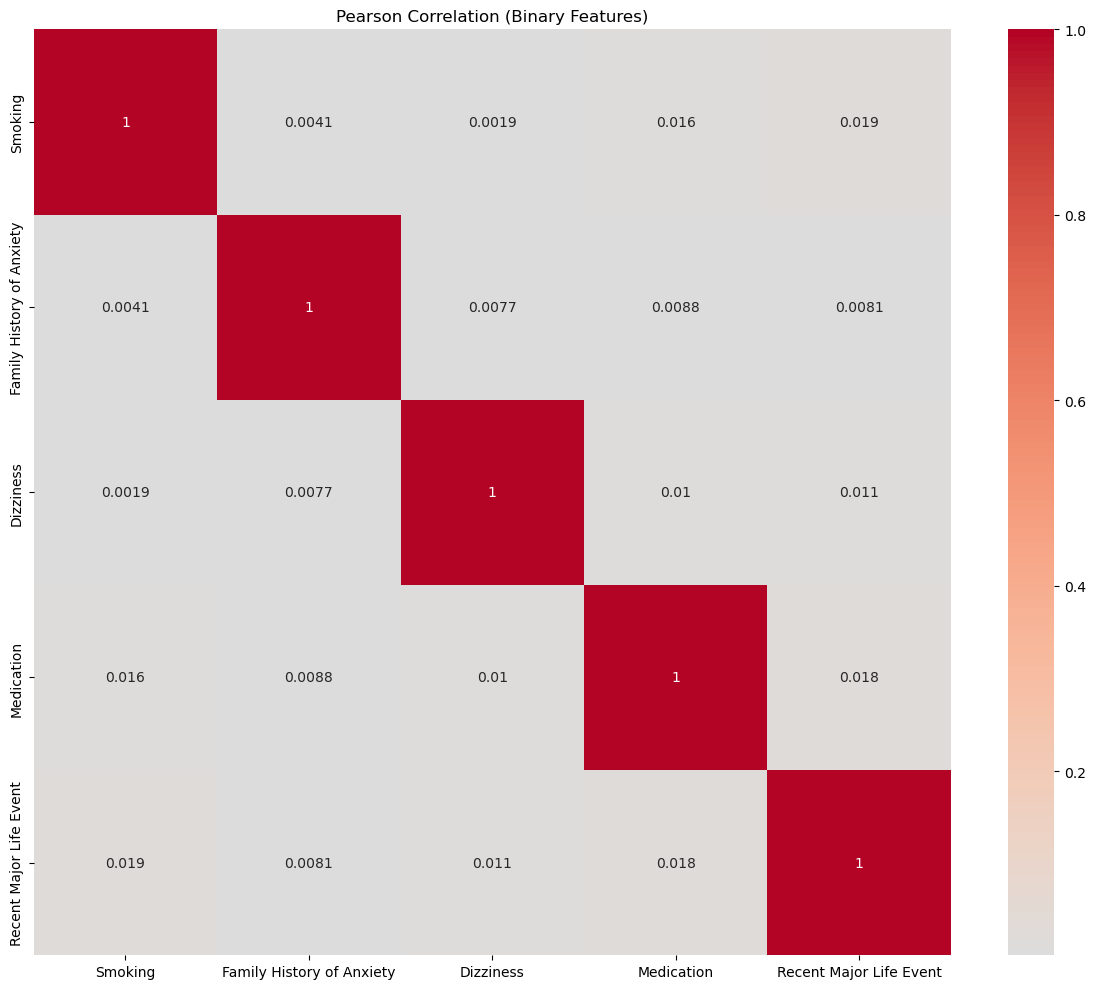

In [37]:
corr_matrix = binary_df.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', center=0)
plt.title('Pearson Correlation (Binary Features)')
plt.tight_layout()
plt.show()

### Check get feature importances of individual features with Lasso model. TODO:Check if match with correlation

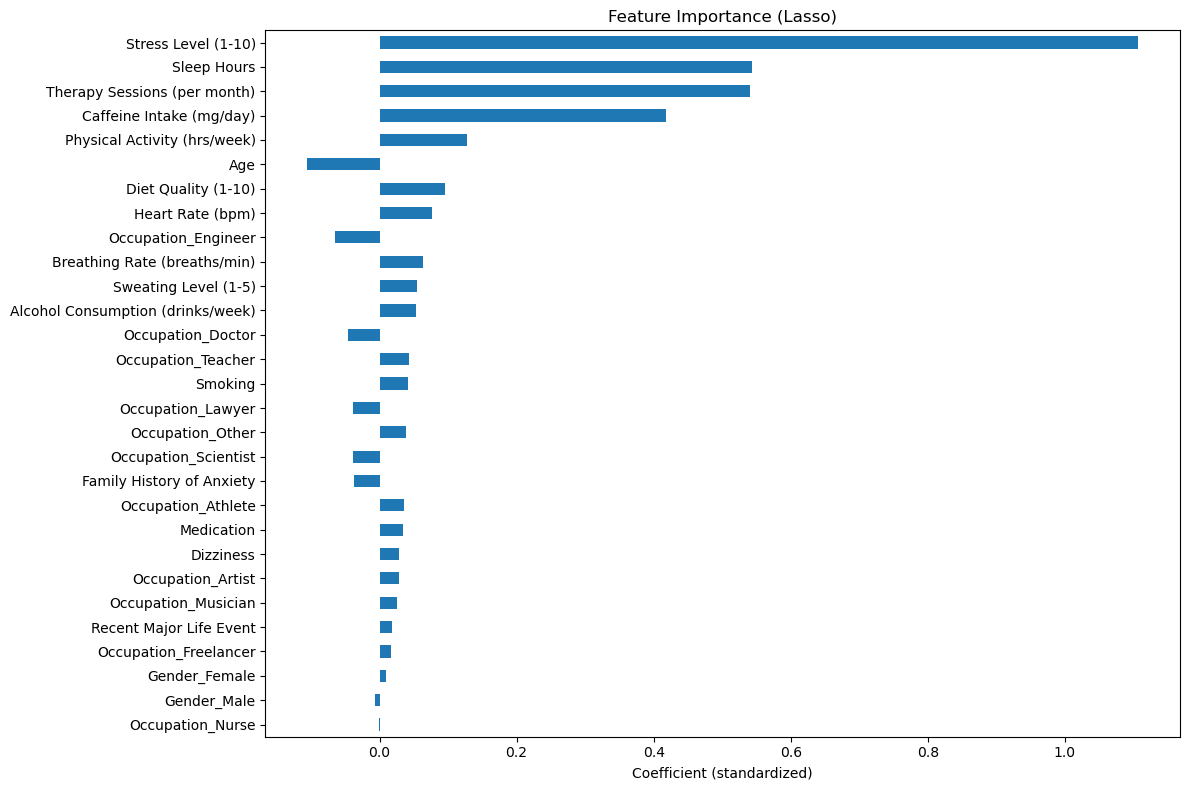

In [48]:
from sklearn.linear_model import LassoCV
X = df.drop(columns=composite_features).drop(columns=target_column_name)
y = df[target_column_name]

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fit lasso
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)


coef = pd.Series(lasso.coef_, index=X.columns)

# show only non-zero features
important_features = coef[coef != 0].sort_values(key=abs, ascending=False)

important_features.plot(kind='barh', title='Feature Importance (Lasso)', figsize=(12, 8
                                                                                 ))
plt.gca().invert_yaxis()
plt.xlabel('Coefficient (standardized)')
plt.tight_layout()
plt.savefig('lasso_feature importances.png')
plt.show()

## Look at specfic instances of correlation and analyze them

### Questions

1. Is there a relationship between Sleep Hours and Anxiety Level?
3. Does Stress Level predict Anxiety Level?

In [12]:
# Converting object columns like 'Smoking' or 'Gender' to category if needed
df['Gender'] = df['Gender'].astype('category')
df['Smoking'] = df['Smoking'].astype('category')
df['Dizziness'] = df['Dizziness'].astype('category')
df['Occupation'] = df['Occupation'].astype('category')


RQ1: Is there a relationship between Sleep Hours and Anxiety Level?
This is a classic correlation task:

Both variables are numeric



What I see:
People report how many hours they sleep and their anxiety levels (on a scale of 1 to 10).

What I think:
"People who sleep less might experience more anxiety. Lack of sleep affects mood and stress response."

So we’re expecting a negative relationship:

More sleep → Less anxiety

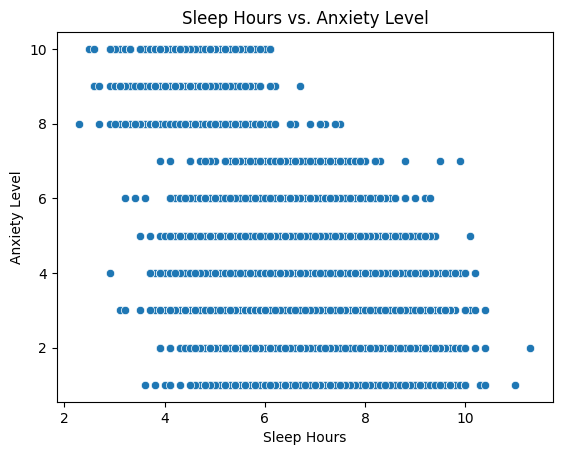

In [26]:
sns.scatterplot(x='Sleep Hours', y='Anxiety Level (1-10)', data=df)
# sns.regplot(x='Sleep Hours', y='Anxiety Level (1-10)', data=df, line_kws={'color': 'red'})
plt.title("Sleep Hours vs. Anxiety Level")
plt.xlabel("Sleep Hours")
plt.ylabel("Anxiety Level")
plt.show()


What I see from the plot:
If the dots tend to slope downward, that suggests:

People who sleep more have lower anxiety
If it’s a messy cloud, then there might not be a strong connection.

The dots are not totally random — there’s a slight downward shape.

When sleep is lower (2–4 hours), there are more people with high anxiety (8–10)

When sleep is higher (8–10 hours), people tend to have lower anxiety (mostly 2–4)

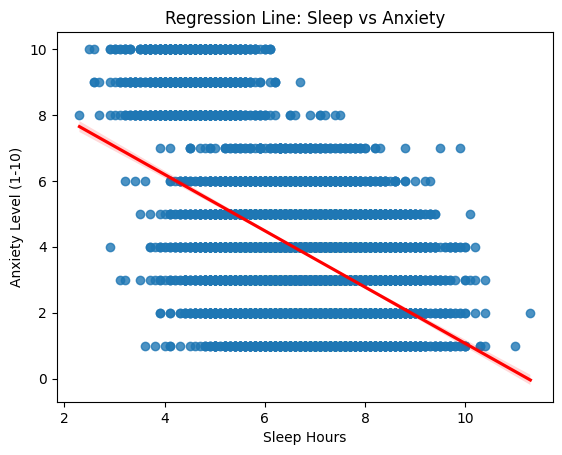

In [23]:
sns.regplot(x='Sleep Hours', y='Anxiety Level (1-10)', data=df, line_kws={'color':'red'})
plt.title("Regression Line: Sleep vs Anxiety")
plt.show()


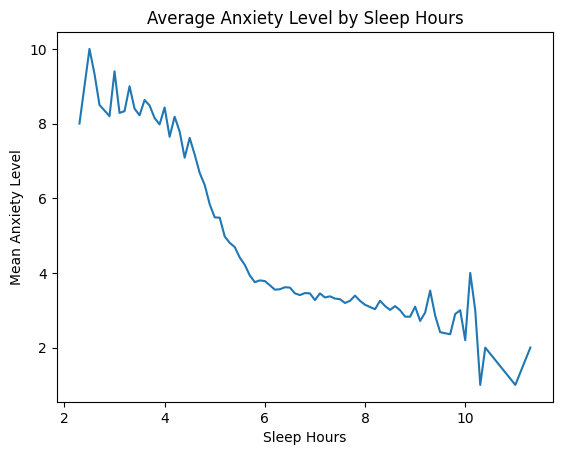

In [25]:
df_grouped = df.groupby('Sleep Hours')['Anxiety Level (1-10)'].mean().reset_index()

sns.lineplot(data=df_grouped, x='Sleep Hours', y='Anxiety Level (1-10)')
plt.title("Average Anxiety Level by Sleep Hours")
plt.ylabel("Mean Anxiety Level")
plt.show()


From 2 to 6 hours: Anxiety levels are very high — above 7–8 on average.

From 6 to 7 hours: Steep drop in average anxiety.

From 7 to 9 hours: Anxiety levels settle around 3–4 — quite low.

Above 10 hours: Values become unpredictable and noisy (probably because very few people sleep this much → small sample size).

### Average Anxiety by Sleep Hours – Interpretation

This line plot shows how the average anxiety level changes based on hours of sleep.

- Individuals with **less than 5 hours of sleep** report **very high anxiety** on average (8+).
- As sleep increases, average anxiety **drops sharply** until around 7 hours.
- After that, anxiety levels remain relatively **low and stable**.
- This supports the idea that **sleep plays a significant role in managing anxiety**.

Note: The small spikes above 10 hours may be due to fewer individuals in that sleep range (less reliable).


In [17]:
#Running a Statistical Test
#We'll use Pearson correlation to measure the strength and direction
from scipy.stats import pearsonr
r, p = pearsonr(df['Sleep Hours'], df['Anxiety Level (1-10)'])
print(f"Pearson Correlation Coefficient: {r:.3f}")
print(f"P-value: {p:.4f}")


Pearson Correlation Coefficient: -0.494
P-value: 0.0000


What I think:
The correlation r = -0.45 means there's a moderate negative correlation.

The p-value = 0.000 means it's statistically significant (p < 0.05).

So I can say:
There’s evidence that more sleep is associated with lower anxiety.
And that supports what we expect from psychology and health research.

In [21]:
# The plot of Sleep Hours only shows how many people sleep 2h, 4h, 6h, etc.
# The plot of Anxiety Level shows how many people have low, medium, or high anxiety.
# To see the independent distributions of sleep hours of people and anxiety level of people


# sns.histplot(df['Sleep Hours'], bins=10, kde=True)
# plt.title("Distribution of Sleep Hours")
# plt.show()

# sns.histplot(df['Anxiety Level (1-10)'], bins=10, kde=True)
# plt.title("Distribution of Anxiety Level")
# plt.show()


RQ3:
"Is there a relationship between stress level and anxiety level?"

Variables:
Stress Level (1-10) → Numeric

Anxiety Level (1-10) → Numeric

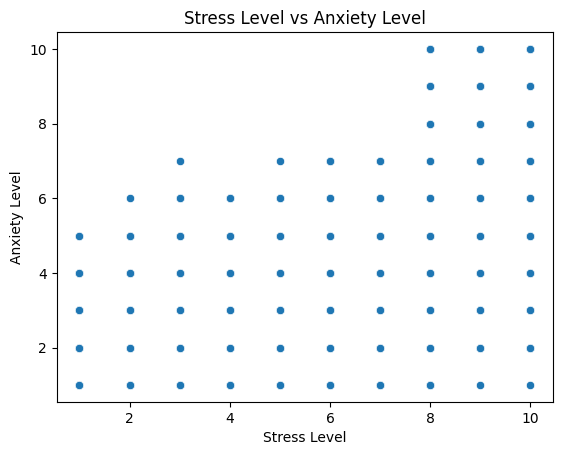

In [32]:
sns.scatterplot(x='Stress Level (1-10)', y='Anxiety Level (1-10)', data=df)
plt.title("Stress Level vs Anxiety Level")
plt.xlabel("Stress Level")
plt.ylabel("Anxiety Level")
plt.show()


In [34]:
# sns.regplot(x='Stress Level (1-10)', y='Anxiety Level (1-10)', data=df, line_kws={"color": "red"})
# plt.title("Regression Line: Stress vs Anxiety")
# plt.show()


In [35]:
from scipy.stats import pearsonr

r, p = pearsonr(df['Stress Level (1-10)'], df['Anxiety Level (1-10)'])
print(f"Correlation Coefficient (r): {r:.3f}")
print(f"P-value: {p:.5f}")


Correlation Coefficient (r): 0.668
P-value: 0.00000


### Stress Level vs Anxiety – Correlation Analysis

We analyzed the relationship between stress levels and anxiety scores.

- **Pearson correlation coefficient**: r = 0.668
- **P-value**: < 0.001

This shows a **strong positive correlation**: as stress levels increase, anxiety scores tend to increase as well.  
The relationship is statistically significant, meaning it is unlikely to be due to chance. This finding supports the well-established link between high stress and increased anxiety.


Doing some more just to see 


"Is there a relationship between how much caffeine a person consumes and their anxiety level?"

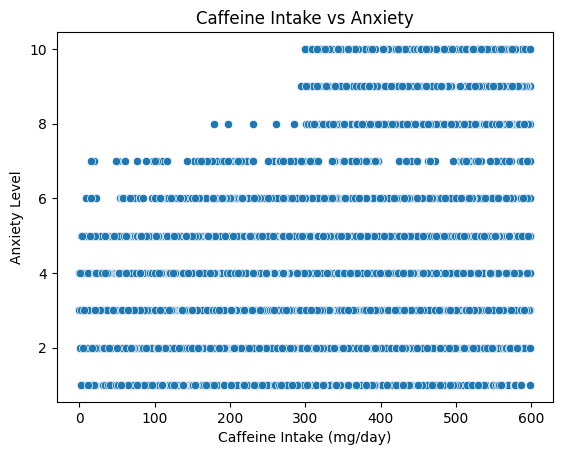

In [37]:
sns.scatterplot(x='Caffeine Intake (mg/day)',y='Anxiety Level (1-10)',data=df)
plt.title('Caffeine Intake vs Anxiety')
plt.xlabel('Caffeine Intake (mg/day)')
plt.ylabel('Anxiety Level')
plt.show()


In [38]:
from scipy.stats import pearsonr

r, p = pearsonr(df['Caffeine Intake (mg/day)'], df['Anxiety Level (1-10)'])
print(f"Correlation Coefficient (r): {r:.3f}")
print(f"P-value: {p:.5f}")


Correlation Coefficient (r): 0.351
P-value: 0.00000


### Caffeine Intake vs Anxiety – Correlation Analysis

We explored the relationship between daily caffeine intake (mg/day) and anxiety level (1–10).

- **Pearson correlation coefficient (r)** = 0.351
- **P-value** < 0.001

The analysis shows a **moderate positive correlation** between caffeine intake and anxiety.  
This indicates that individuals who consume more caffeine tend to report higher levels of anxiety.

The result is **statistically significant**, suggesting this is a meaningful relationship, not random variation.

This finding aligns with psychological research that associates excessive caffeine consumption with heightened arousal and anxiety symptoms.


Derive at least 3 hypotheses:

H1: Less sleep is associated with higher anxiety (confirmed)

H2: There is no significant difference in anxiety between genders (not supported, but tested)

H3: Higher stress levels are associated with higher anxiety (confirmed)

H4: Greater caffeine intake is associated with higher anxiety (confirmed)

# RQ 2: How does Occupation and Gender influence the anxiety level

 Do anxiety levels differ between genders?


What this question means:
We want to see if men and women report different levels of anxiety on average.

This is a Group Comparison problem:
One categorical variable: Gender (Male/Female)

One numeric variable: Anxiety Level (1–10)

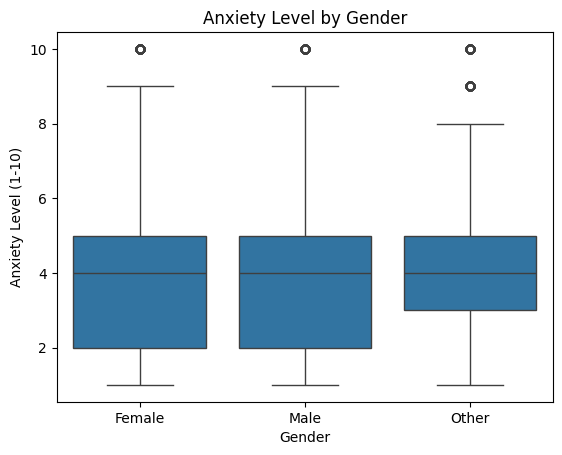

In [28]:
#Boxplot (shows spread and median)
import seaborn as sns
sns.boxplot(x='Gender',y='Anxiety Level (1-10)',data=df)
plt.title('Anxiety Level by Gender')
plt.show()

All three groups have very similar medians (around 4)

The spread is similar — no group has a much wider or tighter range

So visually, there’s no major difference in anxiety between genders

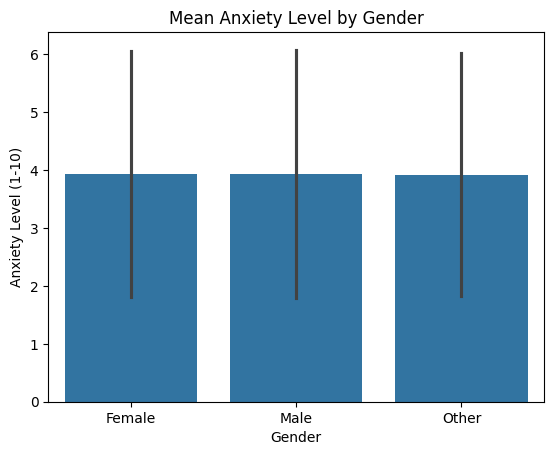

In [30]:
#Barplot (Shows average anxiety)
sns.barplot(x='Gender', y='Anxiety Level (1-10)', data=df, errorbar='sd')
plt.title("Mean Anxiety Level by Gender")
plt.show()


The height of each bar = average anxiety score for each gender

The black line on top of each bar is the standard deviation (error bar)

What you can observe:
All three bars are almost the same height (mean ≈ 3.9)

The error bars overlap a lot, which means:

The differences you see in means could just be due to random variation

This confirms what you saw in the boxplot:
There’s no meaningful difference in anxiety levels across genders based on visuals alone.



In [31]:
#We run a statistical test (t-test) to check if any difference is actually significant.
from scipy.stats import ttest_ind

male = df[df['Gender'] == 'Male']['Anxiety Level (1-10)']
female = df[df['Gender'] == 'Female']['Anxiety Level (1-10)']

t_stat, p_val = ttest_ind(male, female)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")


T-statistic: 0.044
P-value: 0.96494


### Gender vs Anxiety – T-Test Results

We compared average anxiety levels between male and female participants using an independent t-test.

- **T-statistic = 0.044**, **p-value = 0.965**
- This high p-value (> 0.05) tells us that **there is no statistically significant difference** in anxiety levels between genders.
- Visualizations (boxplot and barplot) also showed nearly identical distributions and means.

Therefore Gender does **not** appear to have an effect on anxiety level in this sample.


## Post-hoc Test — Occupation vs Anxiety
Question:
Do anxiety levels differ across multiple occupation groups?

Since this has more than 2 categories, we’ll use:

ANOVA to test if there’s any difference

tukey post-hoc test to find out which groups differ

In [39]:
df['Occupation'].value_counts()

Occupation
Musician      892
Artist        888
Student       878
Nurse         861
Chef          858
Doctor        842
Other         840
Freelancer    838
Engineer      833
Scientist     832
Athlete       822
Lawyer        809
Teacher       807
Name: count, dtype: int64

In [40]:
from scipy.stats import f_oneway

groups = [group['Anxiety Level (1-10)'] for name, group in df.groupby('Occupation')]
f_stat, p_val = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_val:.5f}")


ANOVA F-statistic: 5.080
P-value: 0.00000


C:\Users\Dev\AppData\Local\Temp\ipykernel_23244\2566726352.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['Anxiety Level (1-10)'] for name, group in df.groupby('Occupation')]


An ANOVA test showed a significant difference in anxiety levels across occupation groups:
- F-statistic = 5.080
- p-value < 0.001

This indicates that at least one group differs in average anxiety level.


In [41]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['Anxiety Level (1-10)'],
                          groups=df['Occupation'],
                          alpha=0.05)

print(tukey)


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
    Artist    Athlete   0.0749    1.0 -0.2648  0.4145  False
    Artist       Chef   0.0442    1.0 -0.2918  0.3801  False
    Artist     Doctor   0.4034 0.0051  0.0658  0.7409   True
    Artist   Engineer   0.3419  0.045  0.0034  0.6804   True
    Artist Freelancer   0.1561 0.9494 -0.1819  0.4941  False
    Artist     Lawyer   0.4103 0.0046  0.0692  0.7513   True
    Artist   Musician  -0.0069    1.0 -0.3396  0.3257  False
    Artist      Nurse   0.0586    1.0  -0.277  0.3943  False
    Artist      Other  -0.0319    1.0 -0.3696  0.3059  False
    Artist  Scientist   0.2663 0.3063 -0.0723  0.6049  False
    Artist    Student   0.0877 0.9997 -0.2463  0.4216  False
    Artist    Teacher  -0.0465    1.0 -0.3878  0.2948  False
   Athlete       Chef  -0.0307    1.0 -0.3732  0.3118  False
   Athlete     Doctor   

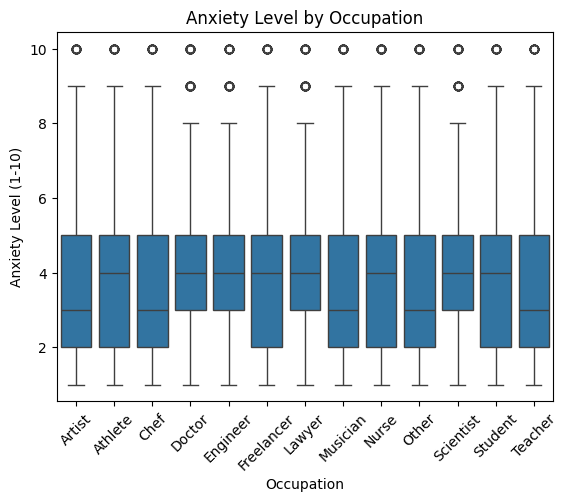

In [42]:
sns.boxplot(x='Occupation', y='Anxiety Level (1-10)', data=df)
plt.title("Anxiety Level by Occupation")
plt.xticks(rotation=45)
plt.show()


To further explore these differences, a **Tukey post-hoc test** was conducted.  
The test identified several **statistically significant pairwise differences**, including:

- **Doctors**, **Lawyers**, and **Engineers** consistently showed **higher anxiety levels** compared to:
  - Artists
  - Musicians
  - Chefs
  - Teachers
  - Others

This suggests that occupations typically associated with high responsibility or performance pressure may be linked to increased anxiety levels.

These findings highlight the potential impact of occupational demands on mental health and support the inclusion of workplace-related factors in anxiety management strategies.


# RQ 3: Can we find significantly different subtypes of high anxiety groups with clustering

In [395]:
df_clustering = df[df[target_column_name] >= 7].drop(columns=composite_features + [target_column_name])
X_scaled_clust = StandardScaler().fit_transform(df_clustering)

clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
clusters = clusterer.fit_predict(X_scaled_clust)

C:\Users\Admin\miniconda3\envs\social-anxiety-analysis\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Admin\miniconda3\envs\social-anxiety-analysis\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Number of noise points: 171


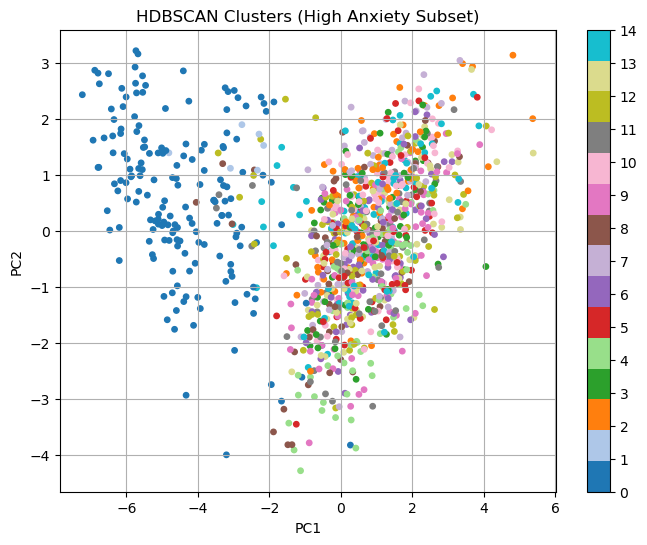

In [405]:
import matplotlib.colors as mcolors

df_clustering['Cluster'] = clusters

n_noise = np.sum(clusters == -1)
print(f"Number of noise points: {n_noise}")


plt.figure(figsize=(8, 6))

# shift cluster to include noise (-1)
colors = np.array(clusters) + 1

# get num of clusters
unique_labels = np.unique(colors)
num_clusters = len(unique_labels)

# get only colors from tab20 that are used
colors_for_clusters = [plt.get_cmap('tab20')(i / (num_clusters)) for i in range(num_clusters)]
custom_cmap = mcolors.ListedColormap(colors_for_clusters)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_clust)
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=colors,
    cmap=custom_cmap,
    s=15,
    vmin=unique_labels.min(),
    vmax=unique_labels.max()
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("HDBSCAN Clusters (High Anxiety Subset)")

cbar = plt.colorbar(scatter, ticks=unique_labels)
plt.grid(True)
plt.show()

In [404]:
df_clustering[target_column_name] = df.loc[df_clustering.index, target_column_name]
groups = [df_clustering[df_clustering['Cluster'] == clust][target_column_name].values 
          for clust in np.unique(df_clustering['Cluster'])]

f_stat, p_val = f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat}")
print(f"ANOVA p-value: {p_val}")

if p_val < alpha:
    print("There is a significant difference in anxiety levels between clusters.")
else:
    print("No significant difference in anxiety levels between clusters.")

ANOVA F-statistic: 30.18138888995585
ANOVA p-value: 2.6135368164443743e-68
There is a significant difference in anxiety levels between clusters.
